In [7]:
# Step 1: Import libraries

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
# Step 2: Create a SQLite database
conn = sqlite3.connect("sales_data.db")

In [9]:
# Step 3: Sample sales data with product, quantity, and price
data = {
    'product': ['Laptop', 'Smartphone', 'Monitor', 'Shirt', 'Laptop', 'Smartphone', 'Book'],
    'quantity': [5, 10, 7, 15, 3, 6, 20],
    'price': [1000, 700, 300, 20, 1000, 700, 15]
}

In [10]:
# Step 4: Create DataFrame and insert into 'sales' table
df = pd.DataFrame(data)
df.to_sql("sales", conn, if_exists="replace", index=False)

7

## ***View Inserted Data***



In [11]:
# Check if data was inserted correctly
query_check = "SELECT * FROM sales"
check_df = pd.read_sql_query(query_check, conn)
check_df

,product,quantity,price
0,Laptop,5,1000
1,Smartphone,10,700
2,Monitor,7,300
3,Shirt,15,20
4,Laptop,3,1000
5,Smartphone,6,700
6,Book,20,15


## ***Run SQL Query to Get Sales Summary***

In [12]:
# Run SQL to get total quantity and revenue per product
query = """
SELECT
    product,
    SUM(quantity) AS total_qty,
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""

summary_df = pd.read_sql_query(query, conn)
summary_df


,product,total_qty,revenue
0,Book,20,300
1,Laptop,8,8000
2,Monitor,7,2100
3,Shirt,15,300
4,Smartphone,16,11200


## ***Print Results***

In [13]:
# Print the result in a nice format
print(" Sales Summary (by Product):")
print(summary_df)


 Sales Summary (by Product):
      product  total_qty  revenue
0        Book         20      300
1      Laptop          8     8000
2     Monitor          7     2100
3       Shirt         15      300
4  Smartphone         16    11200


## ***Plot Bar Chart for Revenue***

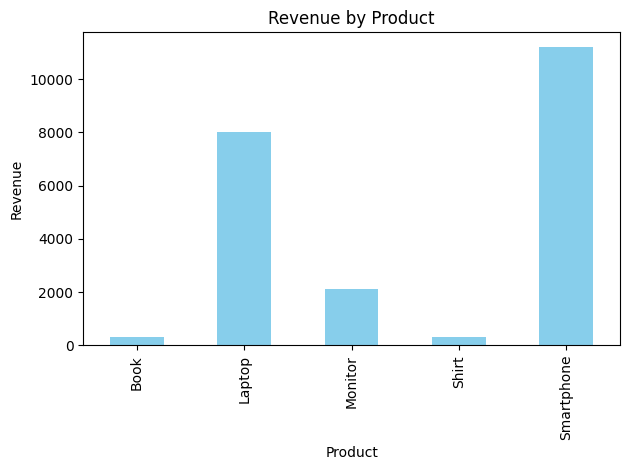

In [23]:

# Bar chart of revenue by product
summary_df.plot(kind='bar', x='product', y='revenue', color='skyblue', legend=False)
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.tight_layout()

plt.savefig("sales_chart.png")
plt.show()


##  Download Files from Colab

In [26]:
from google.colab import files

# Download the database file to your system
files.download("sales_data.db")

# Download the chart image
files.download('sales_chart.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>